In [1]:
from qiskit.circuit import ParameterVector
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

In [2]:
def testf(ab: dict):
    ab["abd"] = 123


a = {"a": 1, "b": 2, "c": 3}
testf(a)
a

{'a': 1, 'b': 2, 'c': 3, 'abd': 123}

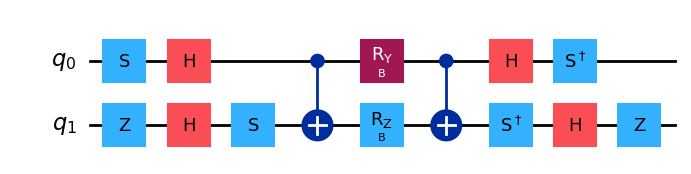

In [3]:


qc = QuantumCircuit(2)
b = Parameter('B')
qc.z(1)
qc.s(0)
qc.h(1)
qc.h(0)
qc.s(1)
qc.cx(0, 1)
qc.ry(b, 0)
qc.rz(b, 1)
qc.cx(0, 1)
qc.h(0)
qc.sdg(1)
qc.sdg(0)
qc.h(1)
qc.z(1)
base_gate = qc.to_gate(label="$R_{XY+YX}$")
qc.draw("mpl")

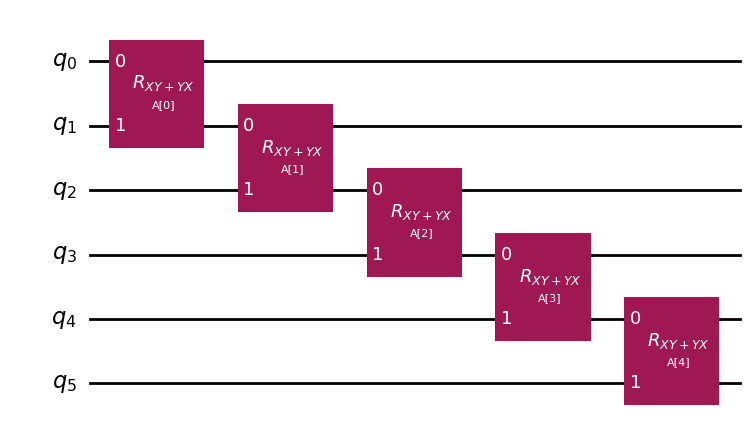

In [4]:
mqc = QuantumCircuit(6)
my_params = ParameterVector("A", 5)
for i in range(5):
    gate = base_gate.copy()
    gate.params[0] = my_params[i]
    # gate = qc.to_gate(label="$R_{XY+YX}$", parameter_map={qc.parameters[0]: my_params[i]})
    mqc.append(gate, [i,i+1])
mqc.draw("mpl")

[0, 1, 2, 3, 25, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
0


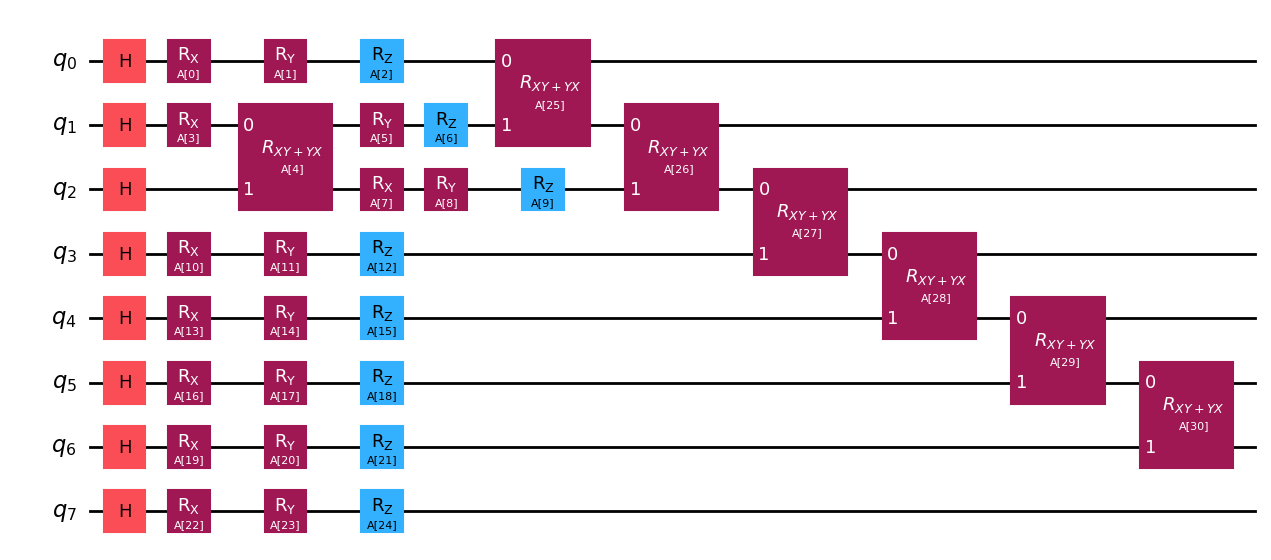

In [10]:
from solver.circuits import YXPlusXYRYAdaptAnsatz1, HardwareAdaptAnsatz1
import random
li = random.sample(range(0, 15), 15)
li = list(range(0, 30))
li.insert(4, 25)
print(li)
temp = HardwareAdaptAnsatz1(8)
print(temp.set_ansatz(li))
temp().draw("mpl")